# Benchmark filterzyme on data from Martinez et al. 

## Choose esterase substrates

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Load substrates from Martinez et al. 
martinez = pd.read_csv('/nvme2/helen/masterthesis/1_manuscript/data/SI_Martinez_et_al_S3.csv', sep=';', encoding='ISO-8859-1') 

# Count number of enzymes that hydrolyzed each ester
target_cols = [col for col in martinez.columns if col.startswith('EH') or col.startswith('Ca')]
martinez['count_hydrolyzed'] =martinez[target_cols].ne(0).sum(axis=1) 
columns_to_drop = ['Ester library', 'Compound chemical class', 'Log P (+/- SD)', 'Unnamed: 3', 'Smiles code',
       'Preparation or commercial source or preparation', 'Brand',
       'Ester concentration [mg/ml]', 'Mw [g/mol]', 'concentration [mM]', 
        'Reaction buffer',
        'Reaction pH',
        'Volume reaction [ml]',
        'Additives (solvents)',
        'Additives (pH indicator)', 
        'Reaction T (¼C)',
        'Enzyme amount [mg]',
        'Reaction time (h)',
        'Shaking [rpm]',
        'Assay method',]

df = martinez.drop(columns=columns_to_drop)

In [2]:
# Keep only non-redundant enzymes and substrates

substrate_col = 'Substrate'
enz_cols = [c for c in df.columns if c != substrate_col]

# Define threshold for "hydrolyzed"
threshold = 0 # > threshold means "hydrolyzed"

# Deduplicate substrates
is_cat = (df[enz_cols] > threshold).fillna(False)
substrate_key = is_cat.astype(int).astype(str).agg(''.join, axis=1)
df_unique_subs = df.loc[~substrate_key.duplicated()].copy()

# Deduplicate enzymes
is_cat_T = is_cat.loc[df_unique_subs.index].T
enzyme_key = is_cat_T.astype(int).astype(str).agg(''.join, axis=1)
unique_enzymes = enzyme_key[~enzyme_key.duplicated()].index

# Keep only unique non-redundant enzymes and substrates 
df_final = df_unique_subs[[substrate_col] + list(unique_enzymes)]

df_final

,Substrate,EH1(72),EH2(71),EH3(69),CalB(68),EH4(67),EH5(67),EH6(66),EH7(64),EH8(63),...,EH128(4),EH129(3),EH130(2),EH131(2),EH135(2),EH136(2),EH138(2),EH139(2),EH140(1),count_hydrolyzed
0,1-Napthyl acetate,865.94,83.97,92.20,10249.91,1.68,8855.73,243.64,15.89,157.91,...,3.84,3.17,5.12,4.16,0.00,3.29,0.00,4.16,1.73,140
1,1-Naphthyl butyrate,614.23,58.57,91.99,2361.28,0.42,5223.53,13.12,5.61,9.03,...,11.63,0.00,0.00,3.22,0.00,0.00,2.19,0.00,0.00,123
2,Glyceryl triacetate,11787.98,96.75,91.09,11181.45,1.93,7171.64,325.26,23.08,2.48,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,108
3,Glyceryl tripropionate,13023.71,97.88,98.37,19898.44,262.23,23520.14,338.55,80.46,163.14,...,0.00,0.00,0.00,0.00,3.94,0.09,0.00,0.00,0.00,126
4,Glyceryl tributyrate,2649.38,112.89,96.33,10936.77,2.12,10518.41,98.89,33.49,111.44,...,1.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Butyl acetate,12464.07,111.42,102.73,63232.81,12.74,14438.20,311.16,11.66,12.58,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,35
92,Phenyl acetate,12577.30,98.25,101.91,64134.88,3.11,16412.72,304.66,9.79,235.19,...,0.00,0.00,0.00,0.00,0.00,0.00,2.83,0.00,0.00,116
93,Phenyl propionate,12244.10,108.17,94.99,63480.44,0.00,15777.62,311.30,77.72,318.17,...,0.00,1.71,23.86,0.00,2.11,0.00,0.00,0.00,0.00,111
94,Glucose pentaacetate,179.54,0.68,104.70,0.00,0.01,1598.46,35.27,8.95,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,61


In [3]:
# Overview over dataset

# Boolean activity matrix
is_cat = (df[enz_cols] > threshold).fillna(False)

# 1) For each substrate: how many enzymes hydrolyze it (row-wise count)
n_enz_per_substrate = is_cat.sum(axis=1).rename('n_enzymes_hydrolyzing')
df_substrate_counts = df[[substrate_col]].assign(n_enzymes_hydrolyzing=n_enz_per_substrate)

# 2) For each enzyme: how many substrates it hydrolyzes (column-wise count)
n_subs_per_enzyme = is_cat.sum(axis=0).rename('n_substrates_hydrolyzed')
df_enzyme_counts = n_subs_per_enzyme.to_frame().rename_axis('enzyme').reset_index()

# (optional) Sort results
df_substrate_counts = df_substrate_counts.sort_values('n_enzymes_hydrolyzing', ascending=False)
df_enzyme_counts = df_enzyme_counts.sort_values('n_substrates_hydrolyzed', ascending=False)

df_enzyme_counts


,enzyme,n_substrates_hydrolyzed
147,count_hydrolyzed,89
0,EH1(72),72
1,EH2(71),71
2,EH3(69),69
3,CalB(68),68
...,...,...
144,EH143(1),1
142,EH141(1),1
141,EH140(1),1
146,EH145(1),1


Total clusters: 15
# clusters with only 1 compound: 3
# clusters with >5 compounds: 3
# clusters with >25 compounds: 1
# clusters with >100 compounds: 0
Ten molecules from largest cluster:


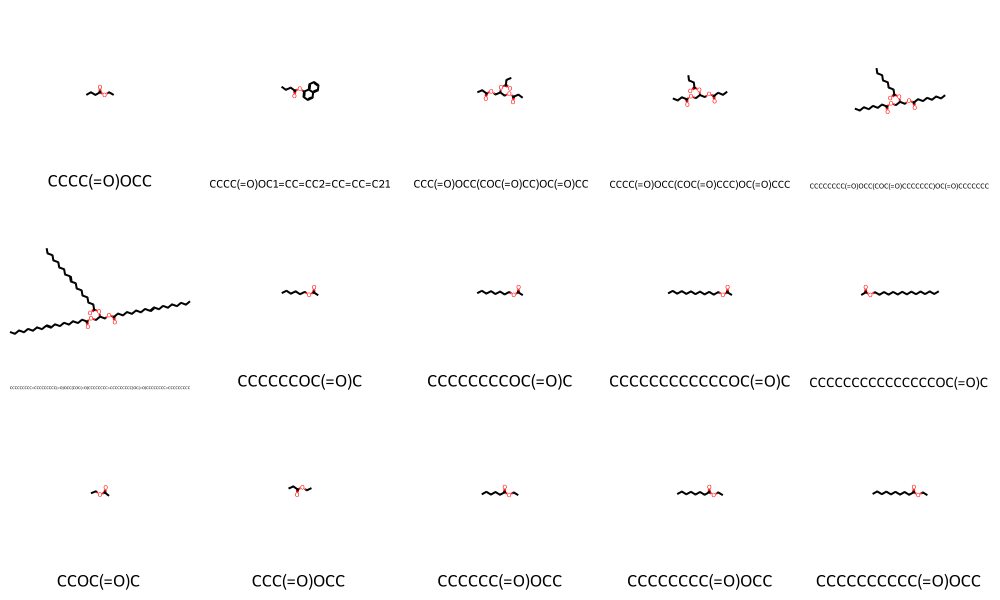

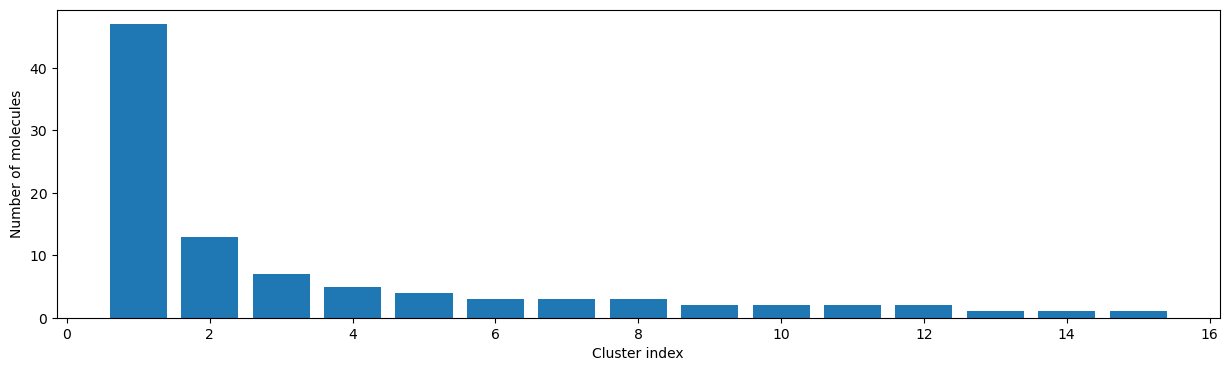

In [4]:
# Calculate Morgan Fingerprints 

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit import DataStructs
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

generator = GetMorganGenerator(radius=2, fpSize=1024)

# Function to convert SMILES to Morgan fingerprints
def get_morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return generator.GetFingerprint(mol)

def fp_to_array(fp):
    arr = np.zeros((fp.GetNumBits(),), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

martinez['MorganFingerprint'] = martinez['Smiles code'].apply(get_morgan_fp)
martinez['MorganFP_bits'] = martinez['MorganFingerprint'].apply(lambda fp: fp_to_array(fp) if fp is not None else None)

# Cluster using Butina Algorithm
from rdkit.ML.Cluster import Butina
from rdkit import Chem
from rdkit.Chem import Draw

def cluster_fingerprints_using_butina(df, fp_column='Fingerprint', cutoff=0.3):
    """Cluster Morgan fingerprints from a df using Butina"""
    
    # Filter out invalid (None) fingerprints
    valid_df = df[df[fp_column].notnull()].copy()
    fps = list(valid_df[fp_column])
    
    # Create distance matrix (upper triangle)
    dists = []
    for i in range(1, len(fps)):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - sim for sim in sims])
    
    # Run Butina clustering
    clusters = Butina.ClusterData(dists, len(fps), cutoff, isDistData=True)
    clusters = sorted(clusters, key=len, reverse=True)

    # Assign cluster labels back to DataFrame
    cluster_labels = [-1] * len(fps)
    for cluster_id, cluster in enumerate(clusters):
        for idx in cluster:
            cluster_labels[idx] = cluster_id
    valid_df['ButinaCluster'] = cluster_labels

    return valid_df, clusters

# Add a Mol column (if not already present)
martinez['Mol'] = martinez['Smiles code'].apply(Chem.MolFromSmiles)

# Cluster
clustered_df, clusters = cluster_fingerprints_using_butina(martinez, fp_column='MorganFingerprint', cutoff=0.7)

# Summarize
num_clust_g1 = sum(1 for c in clusters if len(c) == 1)
num_clust_g5 = sum(1 for c in clusters if len(c) > 5)
num_clust_g25 = sum(1 for c in clusters if len(c) > 25)
num_clust_g100 = sum(1 for c in clusters if len(c) > 100)
print("Total clusters:", len(clusters))
print("# clusters with only 1 compound:", num_clust_g1)
print("# clusters with >5 compounds:", num_clust_g5)
print("# clusters with >25 compounds:", num_clust_g25)
print("# clusters with >100 compounds:", num_clust_g100)

# Plot the size of the clusters to find appropriate cutoff
fig, ax = plt.subplots(figsize=(15, 4))
ax.set_xlabel("Cluster index")
ax.set_ylabel("Number of molecules")
ax.bar(range(1, len(clusters) + 1), [len(c) for c in clusters], lw=5)

# Show 10 molecules from largest cluster
largest_cluster = list(clusters[0][:15])  # 0: largest cluster
subset = clustered_df.iloc[largest_cluster]
print("Ten molecules from largest cluster:")
img = Draw.MolsToGridImage(
    subset['Mol'].tolist(),
    legends=subset['Smiles code'].tolist(),  # or 'Compound Name' if available
    molsPerRow=5,
    subImgSize=(200, 200)
)
img


In [5]:
# Show cluster centroids

cluster_centers = [clustered_df.iloc[c[0]] for c in clusters]
cluster_centers_df = pd.DataFrame(cluster_centers)
cluster_centers_df = cluster_centers_df.reset_index(drop=True)[['Smiles code', 'Mol']]  # Add other columns if needed

print("Cluster centers with 'Substrate', 'count_hydrolyzed', and cluster size:")
print("-" * 70)

for i, cluster in enumerate(clusters):
    center = clustered_df.iloc[cluster[0]]
    substrate = center.get('Substrate', 'N/A')  # ✅ Substrate name
    count = center.get('count_hydrolyzed', 'N/A')
    size = len(cluster)

    print(f"Cluster {i:2d} | Size: {size:3d} | Substrate: {substrate} | count_hydrolyzed: {count}")

# Draw strucutres
img = Draw.MolsToGridImage(
    cluster_centers_df['Mol'].tolist(),
    legends=[f"Cluster {i}" for i in range(len(cluster_centers_df))],
    molsPerRow=5,
    subImgSize=(200, 200)
)
img 

print("Clusters with more than 1 member:")
print("-" * 80)

for i, cluster in enumerate(clusters):
    if len(cluster) > 0:  # Only clusters with more than 1 member
        print(f"\nCluster {i:2d} | Size: {len(cluster)}")
        for idx in cluster:
            member = clustered_df.iloc[idx]
            substrate = member.get('Substrate', 'N/A')
            count = member.get('count_hydrolyzed', 'N/A')
            smiles = member.get('Smiles code', 'N/A')
            print(f"  Member idx {idx} | Substrate: {substrate} | count_hydrolyzed: {count} | SMILES: {smiles}")


Cluster centers with 'Substrate', 'count_hydrolyzed', and cluster size:
----------------------------------------------------------------------
Cluster  0 | Size:  47 | Substrate: Ethyl butyrate | count_hydrolyzed: 32
Cluster  1 | Size:  13 | Substrate: n-Pentyl benzoate | count_hydrolyzed: 11
Cluster  2 | Size:   7 | Substrate: (+)-Methyl (S)-3-hydroxyvalerate | count_hydrolyzed: 33
Cluster  3 | Size:   5 | Substrate: (1R)-(-)-dimenthyl succinate | count_hydrolyzed: 0
Cluster  4 | Size:   4 | Substrate: Methyl 2-hydroxybenzoate | count_hydrolyzed: 4
Cluster  5 | Size:   3 | Substrate: Vinyl oleate | count_hydrolyzed: 0
Cluster  6 | Size:   3 | Substrate: Glyceryl triacetate | count_hydrolyzed: 108
Cluster  7 | Size:   3 | Substrate: Isobutyl cinnamate | count_hydrolyzed: 14
Cluster  8 | Size:   2 | Substrate: Vinyl acrylate | count_hydrolyzed: 33
Cluster  9 | Size:   2 | Substrate: N-Benzyl-D-proline ethyl ester | count_hydrolyzed: 0
Cluster 10 | Size:   2 | Substrate: DCBDCB | count_h

### Choose 3 medium, 1 hard and 1 easy substrate:

medium: 
- Member idx 61 | Substrate: Vinyl propionate | count_hydrolyzed: 58 | SMILES: CCC(=O)OC=C (Cluster 5)
- Member idx 74 | Substrate: Ethyl 3-oxohexanoate | count_hydrolyzed: 54 | SMILES: CCCC(=O)CC(=O)OCC  (Cluster 0)
- Member idx 70 | Substrate: Geranyl acetate | count_hydrolyzed: 43 | SMILES: CC(=CCCC(=CCOC(=O)C)C)C (Cluster 14)

medium alternatives: 
- Member idx 69 | Substrate: Vinyl acrylate | count_hydrolyzed: 33 | SMILES: C=CC(=O)OC=C (Cluster 8)
- Member idx 94 | Substrate: Glucose pentaacetate | count_hydrolyzed: 61 | SMILES: CC(=O)OCC(C(C(C(C=O)OC(=O)C)OC(=O)C)OC(=O)C)OC(=O)C (Cluster 6)

hard: 
- Member idx 80 | Substrate: L-Pantolactone | count_hydrolyzed: 3 | SMILES: CC1(COC(=O)[C@H]1O)C

easy: 
- Member idx 0 | Substrate: 1-Napthyl acetate | count_hydrolyzed: 140 | SMILES: CC(=O)OC1=CC=CC2=CC=CC=C21

## Choose esterases

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Load substrates from Martinez et al. 
martinez_esterases = pd.read_csv('/nvme2/helen/masterthesis/1_manuscript/data/SI_Martinez_et_al_S1.csv', sep=';', encoding='ISO-8859-1') 

martinez_esterases = martinez_esterases[
    martinez_esterases['ID enzyme'].notna() & 
    martinez_esterases['AMINO ACID SEQUENCE'].notna()
].copy()

# We consider all esterases, they only considered EHs that hydrolyzed 10 or more esters

In [7]:
martinez_esterases

,ID enzyme,Accesion number,PDB code,Family,Nr of ester hydrolyzed,Catalytic triad Cavity Volume/SASA,Max specific activity (U/g wet cells),Replicates,Phylum or Domain,Genera or order or family,...,Cloning or expression system,Antibiotic [µg/ml],Inducer,Temp. for expression (¼C),Time for expression (h),Reference for expression and purification conditions,% Identity,Best_hit_NCBInr,Molecular Weight (Da),Isoelectric point (pI)
0,EH1(72),SRA059294,5JD4,FIV,72.0,166.667,1326.63,3.0,Proteobacteria,Sphingomonas,...,Ek/LIC 46 & E. coli BL22,Ampicillin (50),Isopropyl ?-D-1-thiogalactopyranoside (IPTG) (...,37¼C,16 h,"Martnez-Martnez, M., et al. Biochemical dive...",82.86,WP_020694157.1,33936.23,4.858
1,EH2(71),KY483643,NaN,FIV,71.0,500.000,113.26,3.0,Proteobacteria,Rhizobiales,...,pBXNH3 & E. coli MC1061,Ampicillin (50),Arabinose (1.33 mM),37¼C,16 h,This study,81.23,WP_029640596.1,36392.62,4.942
2,EH3(69),KY483645,NaN,FIV,69.0,200.000,106.35,3.0,Proteobacteria,Hyphomonas,...,pBXNH3 & E. coli MC1061,Ampicillin (50),Arabinose (1.33 mM),37¼C,16 h,This study,65.77,AKJ87259.1,37760.99,4.478
3,CalB(68),4K6G_A,4K6G_A,Yeast class,68.0,200.000,"69105,0625 (* in U/g protein)",3.0,Yeast,Candida,...,Commercial preparation,Commercial preparation,Commercial preparation,Commercial preparation,Commercial preparation,Commercial preparation,100.00,4K6H,33466.99,5.202
4,EH4(67),KR107250,NaN,FIV,67.0,500.000,262.23,3.0,Proteobacteria,Rhizobiales,...,Ek/LIC 46 & E. coli BL22,Ampicillin (50),Isopropyl ?-D-1-thiogalactopyranoside (IPTG) (...,37¼C,16 h,This study,78.53,WP_029640596.1,36516.80,5.964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,EH141(1),KP347777,NaN,FVIII (serine beta-lactamase like),1.0,NaN,2.55,3.0,Proteobacteria,Caulobacterales,...,p15Tv-L & E. coli BL21(DE3),Kanamycin (50),Isopropyl ?-D-1-thiogalactopyranoside (IPTG) (...,37¼C,16 h,"Popovic, A., et al. Activity screening of envi...",99.35,AKJ87272.1,49467.10,9.392
143,EH142(1),KP347713,NaN,FI,1.0,NaN,0.25,3.0,Bacteria,Undetermined,...,p15Tv-L & E. coli BL21(DE3),Kanamycin (50),Isopropyl ?-D-1-thiogalactopyranoside (IPTG) (...,37¼C,16 h,"Popovic, A., et al. Activity screening of envi...",51.93,WP_035263123.1,39998.47,5.575
144,EH143(1),KP347716,NaN,Unclassified (no hit in LED),1.0,55.556,1.31,3.0,Synergistetes,Undetermined,...,p15Tv-L & E. coli BL21(DE3),Kanamycin (50),Isopropyl ?-D-1-thiogalactopyranoside (IPTG) (...,37¼C,16 h,"Popovic, A., et al. Activity screening of envi...",90.00,AKJ87217,72440.29,5.019
145,EH144(1),KP347723,NaN,Unclassified,1.0,19.231,1.80,3.0,Bacteroidetes,Undetermined,...,p15Tv-L & E. coli BL21(DE3),Kanamycin (50),Isopropyl ?-D-1-thiogalactopyranoside (IPTG) (...,37¼C,16 h,"Popovic, A., et al. Activity screening of envi...",46.09,CDE60981.1,24853.53,6.760


## Prepare input file

In [8]:
# Prepare esterase df: We need to clean AA sequence and add the UniprotIDs to the df

import re

def remove_parentheses(name):
    if not isinstance(name, str):
        return name
    return re.sub(r'\(.*?\)', '', name)

def clean_sequence(seq: str) -> str:
    """
    Cleans a protein sequence by:
    - Removing stop codons (*)
    - Removing whitespace or newline characters
    - Ensuring only valid amino acid letters remain (A-Z except B, J, O, U, X, Z)
    """
    if pd.isna(seq):
        return None
    seq = seq.upper()
    seq = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', seq)  # Keep only standard 20 amino acids
    return seq

martinez_esterases['cleaned ID enzyme'] = martinez_esterases['ID enzyme'].apply(remove_parentheses)
martinez_esterases = martinez_esterases.rename(columns={'AMINO ACID SEQUENCE': 'Sequence'})
martinez_esterases['Sequence'] = martinez_esterases['Sequence'].apply(clean_sequence)


# Define substrate smiles and names

substrates = {
    'Vinyl_propionate': 'CCC(=O)OC=C',
    'Ethyl_3_oxohexanoate': 'CCCC(=O)CC(=O)OCC',
    'Geranyl_acetate': 'CC(=CCCC(=CCOC(=O)C)C)C',
    'L_Pantolactone': 'CC1(COC(=O)[C@H]1O)C',
    '1_Napthyl_acetate': 'CC(=O)OC1=CC=CC2=CC=CC=C21',
}

difficulty = {
    'Vinyl_propionate': 'medium', 
    'Ethyl_3_oxohexanoate': 'medium',
    'Geranyl_acetate': 'medium',
    'L_Pantolactone': 'hard',
    '1_Napthyl_acetate': 'easy',
}

substrate_rows = pd.DataFrame([
    {
        'substrate_name': name,
        'substrate_smiles': substrates[name],
        'difficulty': difficulty[name]
    }
    for name in substrates
])

# Every enzyme combined with each substrate
df_expanded = martinez_esterases.merge(substrate_rows, how='cross')
df_expanded['Entry'] = df_expanded['cleaned ID enzyme'] + '_' + df_expanded['substrate_name']

# Add rest of columns
df_expanded['cofactor_name'] = None
df_expanded["substrate_moiety"] =  "[C](=O)[O][C]" 
df_expanded

#df_expanded.to_pickle('martinez_input_df.pkl')


,ID enzyme,Accesion number,PDB code,Family,Nr of ester hydrolyzed,Catalytic triad Cavity Volume/SASA,Max specific activity (U/g wet cells),Replicates,Phylum or Domain,Genera or order or family,...,Best_hit_NCBInr,Molecular Weight (Da),Isoelectric point (pI),cleaned ID enzyme,substrate_name,substrate_smiles,difficulty,Entry,cofactor_name,substrate_moiety
0,EH1(72),SRA059294,5JD4,FIV,72.0,166.667,1326.63,3.0,Proteobacteria,Sphingomonas,...,WP_020694157.1,33936.23,4.858,EH1,Vinyl_propionate,CCC(=O)OC=C,medium,EH1_Vinyl_propionate,None,[C](=O)[O][C]
1,EH1(72),SRA059294,5JD4,FIV,72.0,166.667,1326.63,3.0,Proteobacteria,Sphingomonas,...,WP_020694157.1,33936.23,4.858,EH1,Ethyl_3_oxohexanoate,CCCC(=O)CC(=O)OCC,medium,EH1_Ethyl_3_oxohexanoate,None,[C](=O)[O][C]
2,EH1(72),SRA059294,5JD4,FIV,72.0,166.667,1326.63,3.0,Proteobacteria,Sphingomonas,...,WP_020694157.1,33936.23,4.858,EH1,Geranyl_acetate,CC(=CCCC(=CCOC(=O)C)C)C,medium,EH1_Geranyl_acetate,None,[C](=O)[O][C]
3,EH1(72),SRA059294,5JD4,FIV,72.0,166.667,1326.63,3.0,Proteobacteria,Sphingomonas,...,WP_020694157.1,33936.23,4.858,EH1,L_Pantolactone,CC1(COC(=O)[C@H]1O)C,hard,EH1_L_Pantolactone,None,[C](=O)[O][C]
4,EH1(72),SRA059294,5JD4,FIV,72.0,166.667,1326.63,3.0,Proteobacteria,Sphingomonas,...,WP_020694157.1,33936.23,4.858,EH1,1_Napthyl_acetate,CC(=O)OC1=CC=CC2=CC=CC=C21,easy,EH1_1_Napthyl_acetate,None,[C](=O)[O][C]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,EH145(1),KP347726,NaN,FI,1.0,NaN,2.48,3.0,Bacteria,Undetermined,...,WP_012173789.1,35267.83,9.265,EH145,Vinyl_propionate,CCC(=O)OC=C,medium,EH145_Vinyl_propionate,None,[C](=O)[O][C]
731,EH145(1),KP347726,NaN,FI,1.0,NaN,2.48,3.0,Bacteria,Undetermined,...,WP_012173789.1,35267.83,9.265,EH145,Ethyl_3_oxohexanoate,CCCC(=O)CC(=O)OCC,medium,EH145_Ethyl_3_oxohexanoate,None,[C](=O)[O][C]
732,EH145(1),KP347726,NaN,FI,1.0,NaN,2.48,3.0,Bacteria,Undetermined,...,WP_012173789.1,35267.83,9.265,EH145,Geranyl_acetate,CC(=CCCC(=CCOC(=O)C)C)C,medium,EH145_Geranyl_acetate,None,[C](=O)[O][C]
733,EH145(1),KP347726,NaN,FI,1.0,NaN,2.48,3.0,Bacteria,Undetermined,...,WP_012173789.1,35267.83,9.265,EH145,L_Pantolactone,CC1(COC(=O)[C@H]1O)C,hard,EH145_L_Pantolactone,None,[C](=O)[O][C]
